# What does a WR look like the year *before* a breakout?

**Question:** Before a wide receiver's first big season, did he already show signs (elite separation, efficiency on limited volume, youth, draft capital) that could have flagged him in advance?

**Definitions**
- **Breakout** = a WR's *first-ever* top-24 season in PPR points per game (8+ games).
- **Candidate pool** = every WR season from 2016–2024 with 6+ games and 100+ routes, from a player who had **not yet** had a top-24 season. Each one either breaks out the following year or doesn't.
- Rookie-year breakouts (e.g., Ja'Marr Chase, Puka Nacua) can't be studied here because there's no prior NFL season. That's what the college-data phase is for.

Data: `data/processed/player_seasons.parquet` (built by `build_player_seasons.py`). Nothing from the 2026 season is used.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

df = pd.read_parquet("../data/processed/player_seasons.parquet")
wr = df[df["position"] == "WR"].copy()

# Each WR's rank in PPR points per game that season (8+ games only)
qual = wr["games"] >= 8
wr.loc[qual, "ppg_rank"] = wr[qual].groupby("season")["ppr_per_game"].rank(ascending=False, method="first")
wr["top24"] = wr["ppg_rank"] <= 24

# Had he EVER been a top-24 WR before this season?
wr = wr.sort_values(["player_id", "season"])
wr["prior_top24"] = wr.groupby("player_id")["top24"].transform(lambda s: s.shift(fill_value=False).cummax())

# Each player's own role on his team: 1 = most targets on the team
wr = wr.merge(
    df.assign(team_target_rank=df.groupby(["team", "season"])["targets"].rank(ascending=False, method="first"))
      [["player_id", "season", "team_target_rank"]],
    on=["player_id", "season"], how="left")

# Attach NEXT season's result
nxt = wr[["player_id", "season", "top24", "ppg_rank"]].copy()
nxt["season"] -= 1
nxt = nxt.rename(columns={"top24": "next_top24", "ppg_rank": "next_ppg_rank"})
wr = wr.merge(nxt, on=["player_id", "season"], how="left")

In [2]:
pool = wr[
    (wr["season"] <= 2024)            # need a following season to grade
    & (wr["games"] >= 6)
    & (wr["routes"] >= 100)
    & ~(wr["ppg_rank"] <= 24)          # not already a top-24 WR this season
    & ~wr["prior_top24"].astype(bool)  # and never was before
].copy()
pool["breakout"] = (pool["next_top24"] == True).astype(int)

base_rate = pool["breakout"].mean()
print(f"{len(pool)} candidate seasons, {pool['breakout'].sum()} breakouts -> base rate {base_rate:.1%}")

920 candidate seasons, 50 breakouts -> base rate 5.4%


## 1. The breakouts and what they looked like the year before

In [3]:
cols = ["name", "season", "team", "age", "draft_pick", "ppr_per_game", "target_share", "team_target_rank",
        "route_participation", "tprr", "yprr", "avg_separation", "next_ppg_rank"]
pool[pool["breakout"] == 1][cols].sort_values("season").round(2)

,name,season,team,age,draft_pick,ppr_per_game,target_share,team_target_rank,route_participation,tprr,yprr,avg_separation,next_ppg_rank
191,Alshon Jeffery,2016,CHI,26.5,45.0,12.18,0.23,2.0,0.74,0.22,1.88,2.24,24.0
204,Marvin Jones,2016,DET,26.5,166.0,11.49,0.19,2.0,0.88,0.18,1.62,2.05,14.0
260,Adam Thielen,2016,MIN,26.0,NaN,12.32,0.16,3.0,0.79,0.18,1.94,2.75,10.0
308,Robert Woods,2016,BUF,24.4,41.0,9.15,0.20,2.0,0.62,0.22,1.75,3.53,18.0
335,DeAndre Hopkins,2016,HOU,24.2,27.0,12.34,0.26,1.0,0.97,0.25,1.56,2.26,2.0
694,Sterling Shepard,2016,NYG,23.6,40.0,11.52,0.17,2.0,0.98,0.17,1.12,2.74,21.0
752,Robbie Chosen,2016,NYJ,23.3,NaN,8.21,0.17,3.0,0.75,0.17,1.29,2.65,23.0
672,Tyler Lockett,2017,SEA,24.9,69.0,7.77,0.13,4.0,0.74,0.15,1.17,2.88,23.0
1095,Cooper Kupp,2017,LA,24.2,69.0,11.79,0.20,1.0,0.78,0.22,2.01,3.11,15.0
854,Tyler Boyd,2017,CIN,22.8,55.0,5.65,0.09,6.0,0.37,0.16,1.10,NaN,20.0


## 2. Which pre-breakout traits separate breakouts from non-breakouts?

`std_diff` = how far apart the two groups' averages are, in standard deviations (0.2 small, 0.5 medium, 0.8+ large).
`rate_low_25%` / `rate_top_25%` = breakout rate for players in the bottom vs. top quarter of that stat.

In [4]:
features = ["target_share", "ppr_per_game", "xfp_per_game", "yprr", "route_participation", "tprr",
            "tprr_vs_man", "yprr_vs_man", "draft_pick", "age", "years_exp", "avg_yac_above_expectation",
            "avg_intended_air_yards", "avg_separation", "speed_score", "forty", "qb_epa_per_dropback",
            "team_pass_rate_over_exp"]
rows = []
for f in features:
    x = pool.dropna(subset=[f])
    brk, non = x.loc[x["breakout"] == 1, f], x.loc[x["breakout"] == 0, f]
    quartile = pd.qcut(x[f].rank(method="first"), 4, labels=False)
    rate = x.groupby(quartile)["breakout"].mean()
    rows.append({"feature": f, "n": len(x), "breakouts": len(brk),
                 "breakout_median": brk.median(), "others_median": non.median(),
                 "std_diff": (brk.mean() - non.mean()) / x[f].std(),
                 "rate_low_25%": rate.iloc[0], "rate_top_25%": rate.iloc[-1]})
traits = pd.DataFrame(rows).sort_values("std_diff", key=abs, ascending=False)
traits.round(3)

,feature,n,breakouts,breakout_median,others_median,std_diff,rate_low_25%,rate_top_25%
0,target_share,920,50,0.191,0.109,1.397,0.000,0.157
1,ppr_per_game,920,50,11.527,6.066,1.339,0.004,0.165
2,xfp_per_game,920,50,11.098,6.298,1.322,0.000,0.157
3,yprr,920,50,1.771,1.215,1.095,0.004,0.165
4,route_participation,920,50,0.750,0.450,1.065,0.004,0.152
5,tprr,920,50,0.208,0.163,1.013,0.000,0.148
6,tprr_vs_man,702,39,0.260,0.183,0.940,0.006,0.136
7,yprr_vs_man,702,39,1.889,1.223,0.893,0.000,0.131
8,draft_pick,649,47,40.000,91.500,-0.836,0.153,0.006
9,age,920,50,23.700,25.100,-0.655,0.091,0.009


## 3. Testing specific profiles

Includes the original hypothesis: **elite separation while not being the team's #1 target.**

In [5]:
sep_top25 = pool["avg_separation"] >= pool.groupby("season")["avg_separation"].transform(lambda s: s.quantile(0.75))
young, early_pick = pool["age"] <= 24, pool["draft_pick"] <= 64
profiles = {
    "Elite separation (top 25%)": sep_top25,
    "Elite separation + not team's #1 target": sep_top25 & (pool["team_target_rank"] > 1),
    "Targets per route run >= 0.20": pool["tprr"] >= 0.20,
    "Age 24 or younger": young,
    "Drafted rounds 1-2": early_pick,
    "Age <=24 + rounds 1-2 + TPRR >=0.20": young & early_pick & (pool["tprr"] >= 0.20),
    "...and on the field for 70%+ of dropbacks": young & early_pick & (pool["tprr"] >= 0.20) & (pool["route_participation"] >= 0.70),
    "Age 27 or older": pool["age"] >= 27,
}
prof = pd.DataFrame([{"profile": k, "players": int(m.sum()), "breakouts": int(pool.loc[m, "breakout"].sum()),
                      "breakout_rate": pool.loc[m, "breakout"].mean()} for k, m in profiles.items()])
prof["lift_vs_base"] = prof["breakout_rate"] / base_rate
prof.round(3)

,profile,players,breakouts,breakout_rate,lift_vs_base
0,Elite separation (top 25%),129,8,0.062,1.141
1,Elite separation + not team's #1 target,116,5,0.043,0.793
2,Targets per route run >= 0.20,190,29,0.153,2.808
3,Age 24 or younger,322,30,0.093,1.714
4,Drafted rounds 1-2,267,35,0.131,2.412
5,Age <=24 + rounds 1-2 + TPRR >=0.20,52,14,0.269,4.954
6,...and on the field for 70%+ of dropbacks,25,12,0.480,8.832
7,Age 27 or older,243,2,0.008,0.151


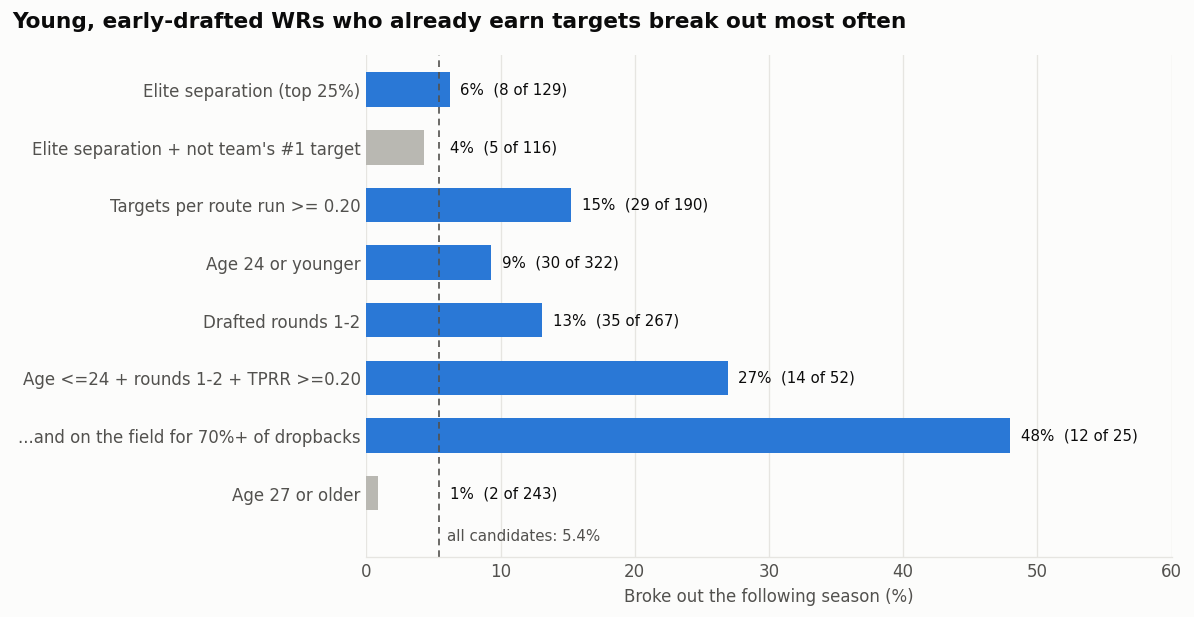

In [6]:
# Chart: breakout rate by profile vs. the base rate
SURF, INK, INK2, GRID, BLUE, GRAY = "#fcfcfb", "#0b0b0b", "#52514e", "#e6e5e1", "#2a78d6", "#b9b8b2"
p = prof.iloc[::-1]
fig, ax = plt.subplots(figsize=(10, 5.2), dpi=120)
fig.patch.set_facecolor(SURF); ax.set_facecolor(SURF)
colors = [BLUE if r > base_rate else GRAY for r in p["breakout_rate"]]
ax.barh(p["profile"], p["breakout_rate"] * 100, color=colors, height=0.6)
ax.axvline(base_rate * 100, color=INK2, lw=1, ls=(0, (4, 3)))
ax.text(base_rate * 100 + 0.6, -0.75, f"all candidates: {base_rate:.1%}", color=INK2, fontsize=9, va="center")
for y, (r, n, b) in enumerate(zip(p["breakout_rate"], p["players"], p["breakouts"])):
    ax.text(max(r, base_rate) * 100 + 0.8, y, f"{r:.0%}  ({b} of {n})", va="center", color=INK, fontsize=9)
ax.set_xlabel("Broke out the following season (%)", color=INK2)
fig.suptitle("Young, early-drafted WRs who already earn targets break out most often",
             x=0.01, ha="left", color=INK, fontsize=13, fontweight="bold")
ax.set_ylim(-1.1, len(p) - 0.4)
ax.grid(axis="x", color=GRID); ax.set_axisbelow(True)
for s in ["top", "right", "left"]: ax.spines[s].set_visible(False)
ax.spines["bottom"].set_color(GRID); ax.tick_params(colors=INK2, length=0)
ax.set_xlim(0, 60)
plt.tight_layout(); plt.show()

## 4. Does the profile hold up out of sample?

The thresholds above were chosen while looking at the data, so they could be overfit. Check the core profile separately in the earlier and later halves of the data.

In [7]:
core = young & early_pick & (pool["tprr"] >= 0.20)
for lo, hi in [(2016, 2020), (2021, 2024)]:
    era = pool["season"].between(lo, hi)
    print(f"{lo}-{hi}: base {pool.loc[era, 'breakout'].mean():.1%} | "
          f"profile {pool.loc[era & core, 'breakout'].mean():.1%} ({int((era & core).sum())} players)")

2016-2020: base 5.6% | profile 17.4% (23 players)
2021-2024: base 5.2% | profile 34.5% (29 players)


## 5. Did the market already know?

A profile only finds *diamonds* if the experts weren't already ranking those players highly.

In [8]:
mk = pool[core & pool["next_preseason_rank"].notna()]
mk[["name", "season", "breakout", "next_preseason_rank", "next_finish_rank"]].sort_values("next_preseason_rank")

,name,season,breakout,next_preseason_rank,next_finish_rank
2036,Garrett Wilson,2023,1,7.0,10.0
1688,Michael Pittman,2021,1,10.0,20.0
2035,Garrett Wilson,2022,0,10.0,26.0
1965,Drake London,2023,1,11.0,5.0
1968,Chris Olave,2022,1,12.0,16.0
1754,CeeDee Lamb,2020,1,12.0,19.0
1597,A.J. Brown,2019,1,18.0,12.0
2242,Marvin Harrison Jr.,2024,0,18.0,50.0
1781,Tee Higgins,2020,1,22.0,24.0
1964,Drake London,2022,0,23.0,37.0


## 6. 2026 candidates (2025 seasons that fit the core profile)

These are *predictions*. 2026 results are the holdout and haven't been used anywhere.

In [9]:
ever_top24 = wr.loc[wr["top24"], "player_id"].unique()
c = wr[(wr["season"] == 2025) & (wr["games"] >= 6) & (wr["routes"] >= 100)
       & ~wr["player_id"].isin(ever_top24) & (wr["age"] <= 24) & (wr["draft_pick"] <= 64) & (wr["tprr"] >= 0.20)]
c[["name", "team", "age", "draft_pick", "ppr_per_game", "target_share", "team_target_rank",
   "route_participation", "tprr", "yprr", "next_preseason_rank"]].sort_values("yprr", ascending=False).round(2)

,name,team,age,draft_pick,ppr_per_game,target_share,team_target_rank,route_participation,tprr,yprr,next_preseason_rank
2310,Luther Burden III,CHI,21.7,39.0,8.53,0.13,5.0,0.38,0.25,2.72,22.0
2273,Emeka Egbuka,TB,22.9,19.0,11.51,0.24,1.0,0.83,0.24,1.77,21.0
2266,Rome Odunze,CHI,23.2,9.0,12.18,0.24,1.0,0.64,0.22,1.62,29.0
2253,Adonai Mitchell,NYJ,22.9,52.0,5.49,0.15,1.0,0.51,0.24,1.46,60.0


## Takeaways

1. **The separation hypothesis didn't hold.** Elite separation alone barely beat the base rate, and elite separation *without* being the #1 target did worse than average. Separation depends heavily on role (short routes inflate it), so it doesn't flag future stars on its own.
2. **Breakouts already earn targets.** The strongest signals were per-route volume: targets per route run (TPRR), yards per route run, and target share. Breakouts typically had ~19% target share the year before, vs. ~11% for non-breakouts.
3. **Youth and draft capital matter a lot.** WRs 27+ almost never had a first breakout (under 1%). Rounds 1-2 picks broke out at 2.4x the base rate.
4. **Combined profile:** age ≤24, drafted rounds 1-2, TPRR ≥0.20 → **about 5x the base rate**, and it held up in both halves of the data. Adding 70%+ route participation pushed it near 50%, but on only 25 players.
5. **Caveats:** small samples (50 breakouts total); thresholds chosen in-sample; the market often ranks these players reasonably high already, so the edge is in the ones it doesn't (e.g., Quentin Johnston and Wan'Dale Robinson were ranked ~60-70 and finished top-17).